## CEAS-08 Dataset, Synthetic with Rewriting

Loading datasets...
Synthetic original data: 1000 rows
Synthetic strong data: 1000 rows
Synthetic weak data: 1000 rows
Train data: 2000 rows
Test data: 1000 rows
Test set: 1000 samples, 500 malicious
Real malicious: 1000
Real benign: 1000

EXPERIMENT 1: REAL-WORLD DATA ONLY (BENIGN + MALICIOUS)

Testing real-world malicious size: 50
  Real malicious: 50
  Real benign: 1000
  Training set: 1050 samples, 50 malicious
  Accuracy: 0.7150
  Precision: 1.0000
  Recall: 0.4300
  F1: 0.6014

Testing real-world malicious size: 100
  Real malicious: 100
  Real benign: 1000
  Training set: 1100 samples, 100 malicious
  Accuracy: 0.8110
  Precision: 1.0000
  Recall: 0.6220
  F1: 0.7670

Testing real-world malicious size: 200
  Real malicious: 200
  Real benign: 1000
  Training set: 1200 samples, 200 malicious
  Accuracy: 0.9050
  Precision: 0.9975
  Recall: 0.8120
  F1: 0.8953

Testing real-world malicious size: 300
  Real malicious: 300
  Real benign: 1000
  Training set: 1300 samples, 300 malici

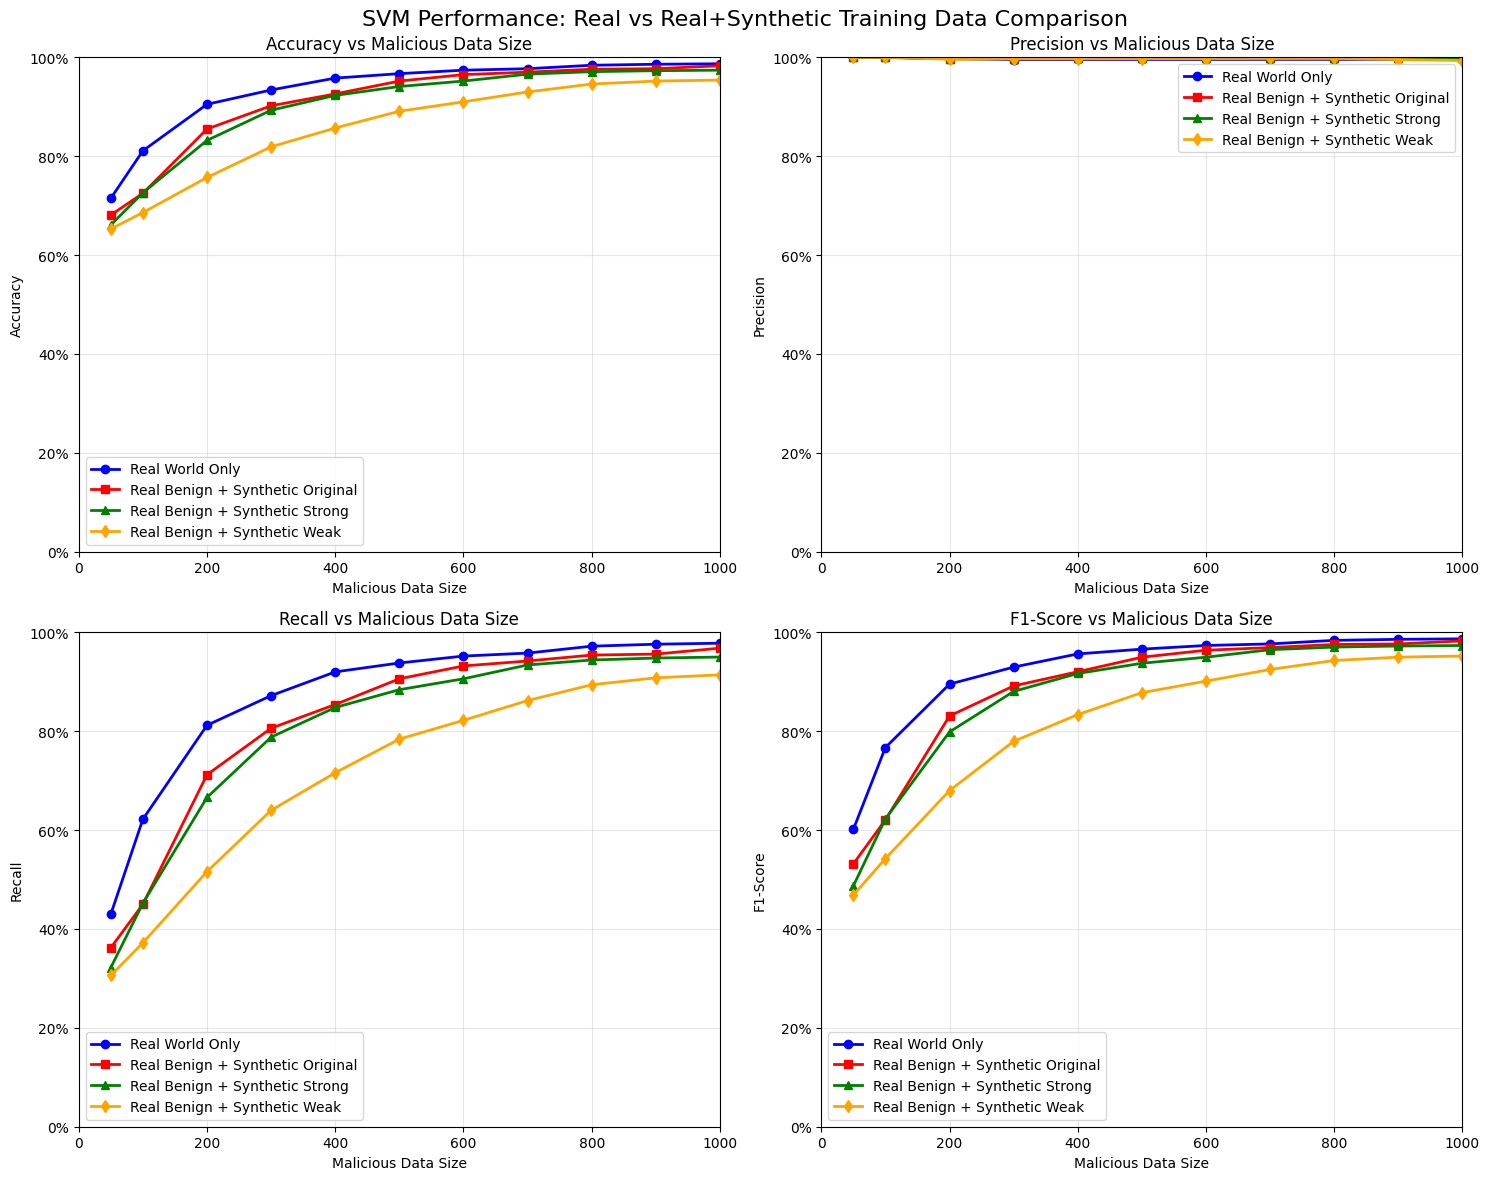


COMPARATIVE ANALYSIS SUMMARY

REAL WORLD ONLY:
Best Accuracy: 0.9870 at 1000 malicious samples
Best Precision: 1.0000 at 50 malicious samples
Best Recall: 0.9780 at 1000 malicious samples
Best F1: 0.9869 at 1000 malicious samples

REAL BENIGN + SYNTHETIC ORIGINAL:
Best Accuracy: 0.9830 at 1000 malicious samples
Best Precision: 1.0000 at 50 malicious samples
Best Recall: 0.9680 at 1000 malicious samples
Best F1: 0.9827 at 1000 malicious samples

REAL BENIGN + SYNTHETIC STRONG:
Best Accuracy: 0.9740 at 1000 malicious samples
Best Precision: 1.0000 at 50 malicious samples
Best Recall: 0.9500 at 1000 malicious samples
Best F1: 0.9734 at 1000 malicious samples

REAL BENIGN + SYNTHETIC WEAK:
Best Accuracy: 0.9540 at 1000 malicious samples
Best Precision: 1.0000 at 50 malicious samples
Best Recall: 0.9140 at 1000 malicious samples
Best F1: 0.9521 at 1000 malicious samples

PERFORMANCE COMPARISON AT KEY SIZES:

Size 100:
  Real World Only F1: 0.7670
  Real Benign + Synthetic Original F1: 0.62

In [1]:
# SVM Classification: Real vs Real+Synthetic Data Comparison
import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# File paths
TRAIN_FILE = "../raw/email_phishing_CEAS-08_train.csv.gz"
TEST_FILE = "../raw/email_phishing_CEAS-08_test.csv.gz"

# New synthetic file paths from data/rewrite/ directory
SYNTHETIC_ORIGINAL_FILE = "../data/rewrite/malicious_original_rewritten.csv.gz"
SYNTHETIC_STRONG_FILE = "../data/rewrite/malicious_strong_rewritten.csv.gz"
SYNTHETIC_WEAK_FILE = "../data/rewrite/malicious_weak_rewritten.csv.gz"

# Configuration
FIXED_BENIGN_SIZE = 1000  # Fixed benign data size
MALICIOUS_SIZES = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]  # Varying malicious sizes

print("Loading datasets...")

# Load datasets
def load_data(file_path):
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        return pd.read_csv(f)

train_df = load_data(TRAIN_FILE)
test_df = load_data(TEST_FILE)

# Load synthetic data
try:
    synthetic_original_df = load_data(SYNTHETIC_ORIGINAL_FILE)
    print(f"Synthetic original data: {len(synthetic_original_df)} rows")
except FileNotFoundError:
    print(f"Warning: {SYNTHETIC_ORIGINAL_FILE} not found. Run real_data_rewriter.py --prompt original first")
    synthetic_original_df = pd.DataFrame()

try:
    synthetic_strong_df = load_data(SYNTHETIC_STRONG_FILE)
    print(f"Synthetic strong data: {len(synthetic_strong_df)} rows")
except FileNotFoundError:
    print(f"Warning: {SYNTHETIC_STRONG_FILE} not found. Run real_data_rewriter.py --prompt strong first")
    synthetic_strong_df = pd.DataFrame()

try:
    synthetic_weak_df = load_data(SYNTHETIC_WEAK_FILE)
    print(f"Synthetic weak data: {len(synthetic_weak_df)} rows")
except FileNotFoundError:
    print(f"Warning: {SYNTHETIC_WEAK_FILE} not found. Run real_data_rewriter.py --prompt weak first")
    synthetic_weak_df = pd.DataFrame()

print(f"Train data: {len(train_df)} rows")
print(f"Test data: {len(test_df)} rows")

# Prepare test data
test_df['combined_text'] = test_df['subject'].fillna('') + ' ' + test_df['body'].fillna('')
X_test = test_df['combined_text']
y_test = test_df['label']

print(f"Test set: {len(y_test)} samples, {y_test.sum()} malicious")

# Prepare real data
real_malicious = train_df[train_df['label'] == 1].copy()
real_benign = train_df[train_df['label'] == 0].copy()

print(f"Real malicious: {len(real_malicious)}")
print(f"Real benign: {len(real_benign)}")

def train_and_evaluate(train_data, experiment_name, malicious_size):
    """Train SVM and evaluate on test data."""
    # Prepare training features
    train_data['combined_text'] = train_data['subject'].fillna('') + ' ' + train_data['body'].fillna('')
    X_train = train_data['combined_text']
    y_train = train_data['label']
    
    print(f"  Training set: {len(y_train)} samples, {y_train.sum()} malicious")
    
    # Vectorize text
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    # Train SVM
    svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    svm.fit(X_train_vec, y_train)
    
    # Predict
    y_pred = svm.predict(X_test_vec)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f}")
    
    return {
        'experiment': experiment_name,
        'malicious_size': malicious_size,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Storage for all results
all_results = []

# Experiment 1: Real-world data only (non-malicious + malicious)
print("\n" + "="*80)
print("EXPERIMENT 1: REAL-WORLD DATA ONLY (BENIGN + MALICIOUS)")
print("="*80)

for malicious_size in MALICIOUS_SIZES:
    print(f"\nTesting real-world malicious size: {malicious_size}")
    
    benign_size = FIXED_BENIGN_SIZE
    
    print(f"  Real malicious: {malicious_size}")
    print(f"  Real benign: {benign_size}")
    
    # Sample real data
    train_samples = []
    
    # Add real malicious samples
    if malicious_size <= len(real_malicious):
        sampled_real_mal = real_malicious.sample(n=malicious_size, random_state=42)
    else:
        sampled_real_mal = real_malicious
    train_samples.append(sampled_real_mal)
    
    # Add benign samples
    if benign_size <= len(real_benign):
        sampled_benign = real_benign.sample(n=benign_size, random_state=42)
    else:
        sampled_benign = real_benign
    train_samples.append(sampled_benign)
    
    # Combine training data
    train_data = pd.concat(train_samples, ignore_index=True)
    train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
    
    # Train and evaluate
    result = train_and_evaluate(train_data, "Real World Only", malicious_size)
    all_results.append(result)

# Experiment 2: Real benign + Synthetic original malicious
if not synthetic_original_df.empty:
    print("\n" + "="*80)
    print("EXPERIMENT 2: REAL BENIGN + SYNTHETIC ORIGINAL MALICIOUS")
    print("="*80)

    for malicious_size in MALICIOUS_SIZES:
        print(f"\nTesting synthetic original malicious size: {malicious_size}")
        
        benign_size = FIXED_BENIGN_SIZE
        
        print(f"  Synthetic original malicious: {malicious_size}")
        print(f"  Real benign: {benign_size}")
        
        # Sample data
        train_samples = []
        
        # Add synthetic original malicious samples
        if malicious_size <= len(synthetic_original_df):
            sampled_synthetic = synthetic_original_df.sample(n=malicious_size, random_state=42)
        else:
            sampled_synthetic = synthetic_original_df
        train_samples.append(sampled_synthetic)
        
        # Add real benign samples
        if benign_size <= len(real_benign):
            sampled_benign = real_benign.sample(n=benign_size, random_state=42)
        else:
            sampled_benign = real_benign
        train_samples.append(sampled_benign)
        
        # Combine training data
        train_data = pd.concat(train_samples, ignore_index=True)
        train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
        
        # Train and evaluate
        result = train_and_evaluate(train_data, "Real Benign + Synthetic Original", malicious_size)
        all_results.append(result)

# Experiment 3: Real benign + Synthetic strong malicious
if not synthetic_strong_df.empty:
    print("\n" + "="*80)
    print("EXPERIMENT 3: REAL BENIGN + SYNTHETIC STRONG MALICIOUS")
    print("="*80)

    for malicious_size in MALICIOUS_SIZES:
        print(f"\nTesting synthetic strong malicious size: {malicious_size}")
        
        benign_size = FIXED_BENIGN_SIZE
        
        print(f"  Synthetic strong malicious: {malicious_size}")
        print(f"  Real benign: {benign_size}")
        
        # Sample data
        train_samples = []
        
        # Add synthetic strong malicious samples
        if malicious_size <= len(synthetic_strong_df):
            sampled_synthetic = synthetic_strong_df.sample(n=malicious_size, random_state=42)
        else:
            sampled_synthetic = synthetic_strong_df
        train_samples.append(sampled_synthetic)
        
        # Add real benign samples
        if benign_size <= len(real_benign):
            sampled_benign = real_benign.sample(n=benign_size, random_state=42)
        else:
            sampled_benign = real_benign
        train_samples.append(sampled_benign)
        
        # Combine training data
        train_data = pd.concat(train_samples, ignore_index=True)
        train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
        
        # Train and evaluate
        result = train_and_evaluate(train_data, "Real Benign + Synthetic Strong", malicious_size)
        all_results.append(result)

# Experiment 4: Real benign + Synthetic weak malicious
if not synthetic_weak_df.empty:
    print("\n" + "="*80)
    print("EXPERIMENT 4: REAL BENIGN + SYNTHETIC WEAK MALICIOUS")
    print("="*80)

    for malicious_size in MALICIOUS_SIZES:
        print(f"\nTesting synthetic weak malicious size: {malicious_size}")
        
        benign_size = FIXED_BENIGN_SIZE
        
        print(f"  Synthetic weak malicious: {malicious_size}")
        print(f"  Real benign: {benign_size}")
        
        # Sample data
        train_samples = []
        
        # Add synthetic weak malicious samples
        if malicious_size <= len(synthetic_weak_df):
            sampled_synthetic = synthetic_weak_df.sample(n=malicious_size, random_state=42)
        else:
            sampled_synthetic = synthetic_weak_df
        train_samples.append(sampled_synthetic)
        
        # Add real benign samples
        if benign_size <= len(real_benign):
            sampled_benign = real_benign.sample(n=benign_size, random_state=42)
        else:
            sampled_benign = real_benign
        train_samples.append(sampled_benign)
        
        # Combine training data
        train_data = pd.concat(train_samples, ignore_index=True)
        train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
        
        # Train and evaluate
        result = train_and_evaluate(train_data, "Real Benign + Synthetic Weak", malicious_size)
        all_results.append(result)

# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Create separate DataFrames for each experiment
real_results = results_df[results_df['experiment'] == 'Real World Only']
synthetic_original_results = results_df[results_df['experiment'] == 'Real Benign + Synthetic Original']
synthetic_strong_results = results_df[results_df['experiment'] == 'Real Benign + Synthetic Strong']
synthetic_weak_results = results_df[results_df['experiment'] == 'Real Benign + Synthetic Weak']

# Display results tables
print("\n" + "="*50)
print("REAL-WORLD DATA ONLY RESULTS")
print("="*50)
if not real_results.empty:
    print(real_results[['malicious_size', 'accuracy', 'precision', 'recall', 'f1']])

print("\n" + "="*50)
print("REAL BENIGN + SYNTHETIC ORIGINAL MALICIOUS RESULTS")
print("="*50)
if not synthetic_original_results.empty:
    print(synthetic_original_results[['malicious_size', 'accuracy', 'precision', 'recall', 'f1']])

print("\n" + "="*50)
print("REAL BENIGN + SYNTHETIC STRONG MALICIOUS RESULTS")
print("="*50)
if not synthetic_strong_results.empty:
    print(synthetic_strong_results[['malicious_size', 'accuracy', 'precision', 'recall', 'f1']])

print("\n" + "="*50)
print("REAL BENIGN + SYNTHETIC WEAK MALICIOUS RESULTS")
print("="*50)
if not synthetic_weak_results.empty:
    print(synthetic_weak_results[['malicious_size', 'accuracy', 'precision', 'recall', 'f1']])

# Plot comparative results
experiments_to_plot = []
experiment_labels = []
experiment_colors = []

if not real_results.empty:
    experiments_to_plot.append(real_results)
    experiment_labels.append('Real World Only')
    experiment_colors.append('blue')

if not synthetic_original_results.empty:
    experiments_to_plot.append(synthetic_original_results)
    experiment_labels.append('Real Benign + Synthetic Original')
    experiment_colors.append('red')

if not synthetic_strong_results.empty:
    experiments_to_plot.append(synthetic_strong_results)
    experiment_labels.append('Real Benign + Synthetic Strong')
    experiment_colors.append('green')

if not synthetic_weak_results.empty:
    experiments_to_plot.append(synthetic_weak_results)
    experiment_labels.append('Real Benign + Synthetic Weak')
    experiment_colors.append('orange')

if experiments_to_plot:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('SVM Performance: Real vs Real+Synthetic Training Data Comparison', fontsize=16)

    metrics = ['accuracy', 'precision', 'recall', 'f1']
    titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    markers = ['o', 's', '^', 'd']

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[i//2, i%2]
        
        # Plot each experiment
        for j, (exp_results, label, color) in enumerate(zip(experiments_to_plot, experiment_labels, experiment_colors)):
            ax.plot(exp_results['malicious_size'], exp_results[metric], 
                    markers[j] + '-', linewidth=2, markersize=6, label=label, color=color)
        
        ax.set_xlabel('Malicious Data Size')
        ax.set_ylabel(title)
        ax.set_title(f'{title} vs Malicious Data Size')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1000)
        ax.set_ylim(0, 1)  # Scale y-axis from 0% to 100%
        ax.legend()
        
        # Format y-axis as percentage
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    plt.tight_layout()
    plt.show()

# Summary statistics
print("\n" + "="*80)
print("COMPARATIVE ANALYSIS SUMMARY")
print("="*80)

for exp_results, label in zip(experiments_to_plot, experiment_labels):
    if not exp_results.empty:
        print(f"\n{label.upper()}:")
        print(f"Best Accuracy: {exp_results['accuracy'].max():.4f} at {exp_results.loc[exp_results['accuracy'].idxmax(), 'malicious_size']} malicious samples")
        print(f"Best Precision: {exp_results['precision'].max():.4f} at {exp_results.loc[exp_results['precision'].idxmax(), 'malicious_size']} malicious samples")
        print(f"Best Recall: {exp_results['recall'].max():.4f} at {exp_results.loc[exp_results['recall'].idxmax(), 'malicious_size']} malicious samples")
        print(f"Best F1: {exp_results['f1'].max():.4f} at {exp_results.loc[exp_results['f1'].idxmax(), 'malicious_size']} malicious samples")

# Performance comparison at specific sizes
print("\n" + "="*60)
print("PERFORMANCE COMPARISON AT KEY SIZES:")
print("="*60)

for size in [100, 500, 1000]:
    print(f"\nSize {size}:")
    
    # Get baseline (real world only)
    baseline_f1 = None
    if not real_results.empty and size in real_results['malicious_size'].values:
        baseline_f1 = real_results[real_results['malicious_size'] == size]['f1'].iloc[0]
        print(f"  Real World Only F1: {baseline_f1:.4f}")
    
    # Compare other experiments to baseline
    for exp_results, label in zip(experiments_to_plot[1:], experiment_labels[1:]):  # Skip real world only
        if not exp_results.empty and size in exp_results['malicious_size'].values:
            exp_f1 = exp_results[exp_results['malicious_size'] == size]['f1'].iloc[0]
            if baseline_f1 is not None:
                diff = exp_f1 - baseline_f1
                print(f"  {label} F1: {exp_f1:.4f} (diff: {diff:+.4f})")
            else:
                print(f"  {label} F1: {exp_f1:.4f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("This comparison shows how synthetic data generated with different prompts")
print("affects model performance compared to using only real-world training data.")
print("="*80)